## Media Politics Group Project Guide

**Group Members**: Erin, Ailie, Cyrus, Nina, Mariam, Martin

**Description**: News media and political leaders both shape and reflect public opinion, but they often frame important political issues differently while also influencing what citizens perceive as salient. This project uses data science to systematically compare government communication and media coverage over time, examining how their relationship changes in response to events such as elections, political scandals, and major policy debates.

**Research Question**: How did the policy agenda emphasized in Prime Minister speeches compare with that of the Japan Times between 2001 and 2021?

**Secondary Research Questions**: Which policy issues received consistently greater attention in Prime Minister speeches versus the Japan Times?
How did sentiment toward shared policy issues differ between Prime Minister speeches and the Japan Times? Can AI-based sentiment analysis effectively capture differences in the tone of government and media discourse, and what methodological challenges arise when applying it to political texts?
Can this analytical framework be generalized to compare political and media discourse in other democratic countries?

**Hypothesis**: 
Hypothesis 1: Prime Minister speeches and The Japan Times will exhibit significant differences in the policy issues they prioritize between 2001 and 2021, reflecting the distinct objectives of government leaders and the news media. Rationale: Government speeches are intended to promote and justify policy agendas, while news media select issues based on newsworthiness, public interest, and editorial priorities.
Hypothesis 2: AI-based text tokenization and sentiment analysis will identify measurable differences in the tone of policy discussions between Prime Minister speeches and The Japan Times*, but its performance will be constrained by the complexity and nuance of political language. Rationale: Political speeches often employ diplomatic, strategic, or deliberately neutral language that may not be fully captured by automated sentiment analysis.


In [1]:
# Import Libraries
import pandas as pd
import sys
import os
import importlib

sys.path.append('..')

## 1. Obtain and Clean Data Sources
Subtitle and description from group 2

#### 1a. Obtaining Data: Webscraping
Some speech datasets like the Japanese Prime Minister speeches were obtained through webscraping. The following is our scraping function for the [The World and Japan Database](https://worldjpn.net/documents/indices/exdpm/index-ENG.html), defined in [`src/scrape_speeches.py`](../src/scrape_speeches.py), and how it was called:

In [2]:
# Import Libraries for Webscraping
import requests
from bs4 import BeautifulSoup
from src.scrape_speeches import SpeechScraper

In [3]:
# Test Response
resp = requests.get("https://worldjpn.net", timeout=15)
print(resp.status_code)

200


In [5]:
# Run python file
scraper = SpeechScraper(delay=1.0)
records = scraper.scrape_all()
df = pd.DataFrame(records)

Fetching index: https://worldjpn.net/documents/indices/exdpm/index-ENG.html
Found 608 English speech links

[1/608] https://worldjpn.net/documents/texts/JPUS/19510907.S1E.html
[2/608] https://worldjpn.net/documents/texts/docs/19770818.S1E.html
[3/608] https://worldjpn.net/documents/texts/exdpm/19880504.S1E.html
[4/608] https://worldjpn.net/documents/texts/exdpm/19910503.S1E.html
[5/608] https://worldjpn.net/documents/texts/exdpm/19910527.S1E.html
[6/608] https://worldjpn.net/documents/texts/exdpm/19920117.S1E.html
[7/608] https://worldjpn.net/documents/texts/exdpm/19920131.S1E.html
[8/608] https://worldjpn.net/documents/texts/exdpm/19920613.S1E.html
[9/608] https://worldjpn.net/documents/texts/exdpm/19920702.S1E.html
[10/608] https://worldjpn.net/documents/texts/exdpm/19921029.S1E.html
[11/608] https://worldjpn.net/documents/texts/exdpm/19940831.S1E.html
[12/608] https://worldjpn.net/documents/texts/JH/19950718.S1E.html
[13/608] https://worldjpn.net/documents/texts/exdpm/19970623.S1E.h

In [6]:
# Display results
speeches_df = df
speeches_df.head(5)

,title,date,place,source,notes,body,url,error
0,Prime Minister Shigeru Yoshida's Speech at the...,"September 7, 1951",San Francisco,"Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",,The peace treaty before the Conference contain...,https://worldjpn.net/documents/texts/JPUS/1951...,NaN
1,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,"August 18, 1977",Manila,The Ministry of Foreign Affairs of Japan,,"President Marcos, Madam Imelda Romualdez Marco...",https://worldjpn.net/documents/texts/docs/1977...,NaN
2,Statement by Prime Minister Takeshita on the O...,"May 4, 1988",London,Ministry of Foreign Affairs of Japan,,Opening a New Era in Japanese-European Relatio...,https://worldjpn.net/documents/texts/exdpm/198...,NaN
3,Policy Speech by Prime Minister Toshiki Kaifu ...,"May 3, 1991",Singapore,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...",,"1. Introduction\n\nDistinguished Guests, ladie...",https://worldjpn.net/documents/texts/exdpm/199...,NaN
4,Address by Prime Minister Toshiki Kaifu at the...,"May 27, 1991","Kyoto, Japan","DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...",,"Ladies and gentlemen,\n\nOn behalf of the Gove...",https://worldjpn.net/documents/texts/exdpm/199...,NaN


In [7]:
# Drop columns not needed and rename remaining columns for uniformity, change depending on source
speeches_df = df.drop(columns={"notes", "url", "error", "place"}).dropna()
speeches_df = speeches_df.rename(columns={"body": "text"})
speeches_df.head(5)

,title,date,source,text
0,Prime Minister Shigeru Yoshida's Speech at the...,"September 7, 1951","Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",The peace treaty before the Conference contain...
1,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,"August 18, 1977",The Ministry of Foreign Affairs of Japan,"President Marcos, Madam Imelda Romualdez Marco..."
2,Statement by Prime Minister Takeshita on the O...,"May 4, 1988",Ministry of Foreign Affairs of Japan,Opening a New Era in Japanese-European Relatio...
3,Policy Speech by Prime Minister Toshiki Kaifu ...,"May 3, 1991","DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","1. Introduction\n\nDistinguished Guests, ladie..."
4,Address by Prime Minister Toshiki Kaifu at the...,"May 27, 1991","DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","Ladies and gentlemen,\n\nOn behalf of the Gove..."


In [8]:
# Convert date column to date-time format, and sort by date
speeches_df['date'] = pd.to_datetime(speeches_df['date'], format='mixed', errors='coerce')
speeches_df = speeches_df.dropna(subset=['date'])
speeches_df = speeches_df.sort_values(by='date')
speeches_df.head(5)

,title,date,source,text
0,Prime Minister Shigeru Yoshida's Speech at the...,1951-09-07,"Gaimusho joyaku-kyoku hokika, Heiwa joyaku no ...",The peace treaty before the Conference contain...
1,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,1977-08-18,The Ministry of Foreign Affairs of Japan,"President Marcos, Madam Imelda Romualdez Marco..."
2,Statement by Prime Minister Takeshita on the O...,1988-05-04,Ministry of Foreign Affairs of Japan,Opening a New Era in Japanese-European Relatio...
3,Policy Speech by Prime Minister Toshiki Kaifu ...,1991-05-03,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","1. Introduction\n\nDistinguished Guests, ladie..."
4,Address by Prime Minister Toshiki Kaifu at the...,1991-05-27,"DIPLOMATIC BLUEBOOK 1991, Japan's Diplomatic A...","Ladies and gentlemen,\n\nOn behalf of the Gove..."


In [9]:
# Display Results and Save CSV
print(speeches_df.info())
#speeches_df.to_csv('pm_speeches_en.csv')

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 0 to 607
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   title   600 non-null    object        
 1   date    600 non-null    datetime64[ns]
 2   source  600 non-null    object        
 3   text    600 non-null    object        
dtypes: datetime64[ns](1), object(3)
memory usage: 23.4+ KB
None


#### 1b. For raw data in CSV form to cleaned data
Ex. japan_english_news_kaggle.csv to japan_news_cleaned.csv

In [10]:
# Define filepath to raw CSV data
filename = 'japan_english_news_kaggle.csv'

filepath = f"../data/raw/{filename}"

In [11]:
# Read CSV to dataframe
news_pd = pd.read_csv(filepath, sep='\t') # sets delimiter to tab, change if needed
news_pd.head(5)

,source,date,title,author,text
0,Mainichi Shimbun,2021-12-06,"Editorial: Japan govt's 20,000-yen handout mis...",NaN,The Japanese government is trying to boost the...
1,Mainichi Shimbun,2021-12-07,Editorial: Time for Japan PM Kishida to delive...,NaN,"Prime Minister Fumio Kishida, who won a public..."
2,Mainichi Shimbun,2021-12-08,"Editorial: 80 years on from Pearl Harbor, acti...",NaN,It has been 80 years since the start of the Pa...
3,Mainichi Shimbun,2021-12-08,"Yoroku: 80 years later, many lessons still not...",NaN,"""The world has changed completely. The era was..."
4,Mainichi Shimbun,2021-12-08,Promoting respect for human rights behind US '...,NaN,The U.S. administration under President Joe Bi...


In [12]:
# Filter and sort by date 2001 - 2021

news_pd['date'] = pd.to_datetime(news_pd['date'])

start_date = '2001-01-01'
end_date = '2021-12-31'

news_pd_filtered = news_pd[news_pd['date'].between(start_date, end_date)]
news_pd_filtered = news_pd_filtered.sort_values(by='date')

news_pd_filtered.head(5)

,source,date,title,author,text
86,The Japan Times,2001-01-01,Life? Martian meteorite keeps its cool,Rowan Hooper,"“X-Files,” eat your heart out. Supporters of t..."
76,The Japan Times,2001-01-01,Economy expected to limp toward recovery,Mayumi Negishi,The consensus among economists at private thin...
75,The Japan Times,2001-01-01,State-backed Internet expo kicks off,NaN,The government-sponsored virtual Internet expo...
74,The Japan Times,2001-01-01,Foreign workforce movin' on up,Tetsushi Kajimoto,"For a long time, workers coming to Japan from ..."
98,The Japan Times,2001-01-01,Can peace be globalized in the 21st century?,Yoshikazu Sakamoto,The 20th century is usually referred to as a c...


In [13]:
# Drop na values in text and title
news_pd_filtered = news_pd_filtered.dropna(subset=['title', 'text'])
news_pd_filtered.head(5)

,source,date,title,author,text
86,The Japan Times,2001-01-01,Life? Martian meteorite keeps its cool,Rowan Hooper,"“X-Files,” eat your heart out. Supporters of t..."
76,The Japan Times,2001-01-01,Economy expected to limp toward recovery,Mayumi Negishi,The consensus among economists at private thin...
75,The Japan Times,2001-01-01,State-backed Internet expo kicks off,NaN,The government-sponsored virtual Internet expo...
74,The Japan Times,2001-01-01,Foreign workforce movin' on up,Tetsushi Kajimoto,"For a long time, workers coming to Japan from ..."
98,The Japan Times,2001-01-01,Can peace be globalized in the 21st century?,Yoshikazu Sakamoto,The 20th century is usually referred to as a c...


In [14]:
# Clean csv info
print(news_pd_filtered.info())

# Save to csv
# JPnews_pd_filtered.to_csv('cleaned.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 36766 entries, 86 to 33
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   source  36766 non-null  object        
 1   date    36766 non-null  datetime64[ns]
 2   title   36766 non-null  object        
 3   author  12724 non-null  object        
 4   text    36766 non-null  object        
dtypes: datetime64[ns](1), object(4)
memory usage: 1.7+ MB
None


Used this method on all raw data in csv form that we obtained from downloaded datasets online or webscraping. 

## 2. Choose Keywords
We chose the specific keywords through utilizing LLM Agent Olama. Asking it the common phrase: "What are 10 political, single-word, simple keywords closely associated with Japan's [category] strategy in english? Please include short explanations for why each were chosen.")

Included capital and lowercase as well as different english spelling to account for specific english translations (UK English vs. American English)

Install ollama app
ollama serve
pull ollama model thingy

In [ ]:
put the 2 cells of ollama code

In [2]:
CATEGORY_KEYWORDS = {
    "defense": {
        "self defense", "self defence", "ASEAN", "US-Japan Alliance", 
        "NATO", "Triton", "triton", "Maritime Security","maritime security", "DFNS", "Intelligence-Led Operations",
        "Cybersecurity", "cybersecurity", "Alliance Deterrence" "alliance deterrence",
    },
    "economy": {"Abenomics", "stimulus", "monetization", "monetisation", "deflationary", "Abe doctrine", "sustainable growth", "structural reform", 
                "export-led growth", "demographic shift", "stable growth", "Abenomics", "Stimulus", "Monetization", "Deflationary", 
                "Abe doctrine", "Sustainable growth", "Structural reform", "Export-led growth", "Demographic shift", "Stable growth"
    },
    "nuclear": {
        "Deterrence", "Non-proliferation", "Alliance", "Self-defense", "NPT", "SDGT", 
        "Takeshima", "ASEAN", "US-Japan Security Treaty", "Peaceful use", "deterrence",
        "non-proliferation", "alliance", "self-defense",  "peaceful use"
    },
    "immigration": {
        "Quota", "Skilled", "Guestworker", "Refugee", "Integration", 
        "Citizenship", "Asylum", "Pathway", "Talent", "Inclusion", "quota", "skilled", "guestworker", "refugee", "integration", 
        "citizenship", "asylum", "pathway", "talent", "inclusion"
    },
}

## 3. Tokenize Text Data and Count Words
link to files that tokenize data and count words etc.

## 4. Keyword Statistics
Basic Statistics, Word Clouds 

Basic visualization for the number of speeches that mention keywords from each identiifed category within the same time period as the news articles (2004-2021)

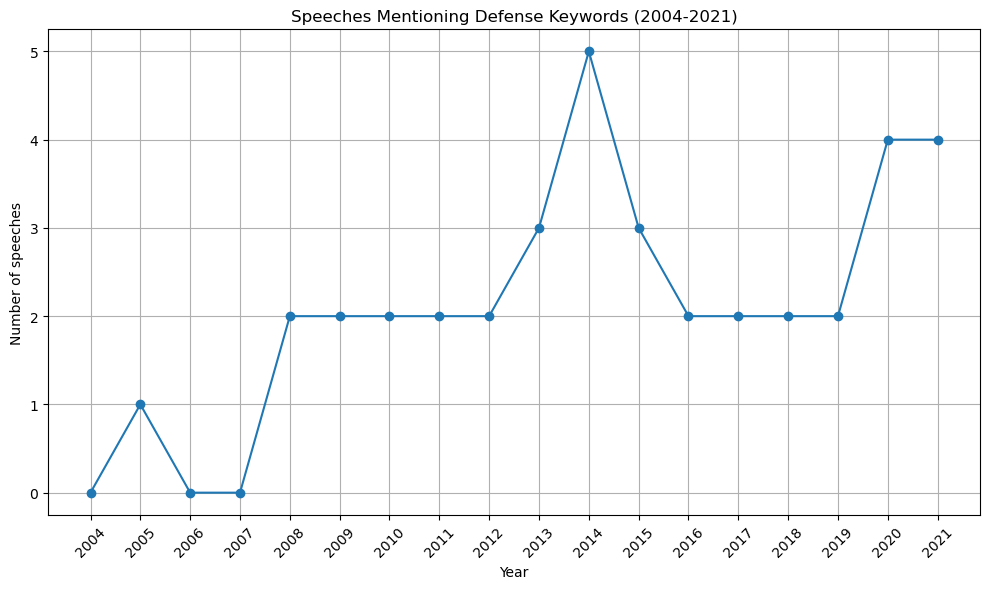

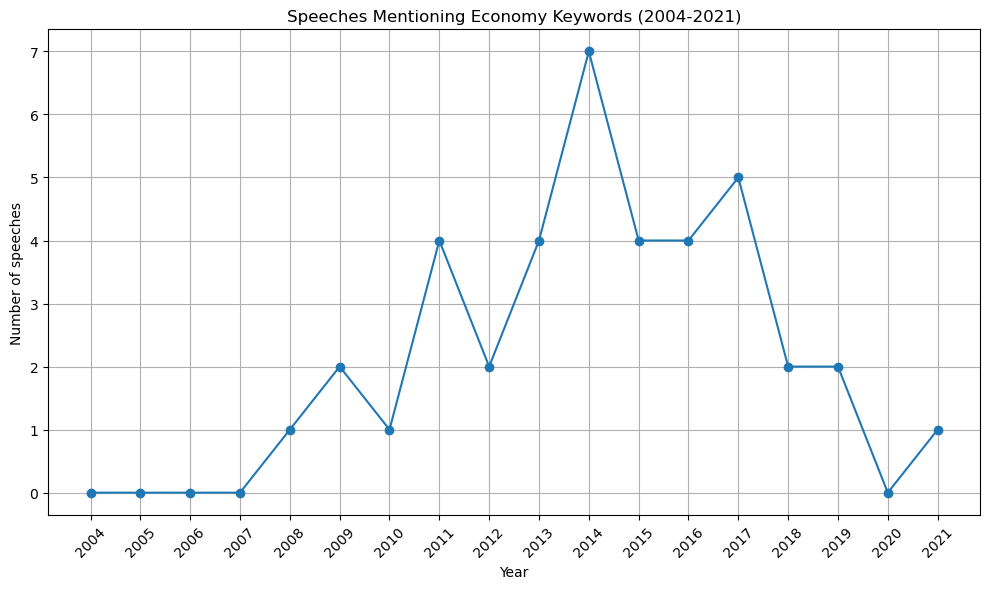

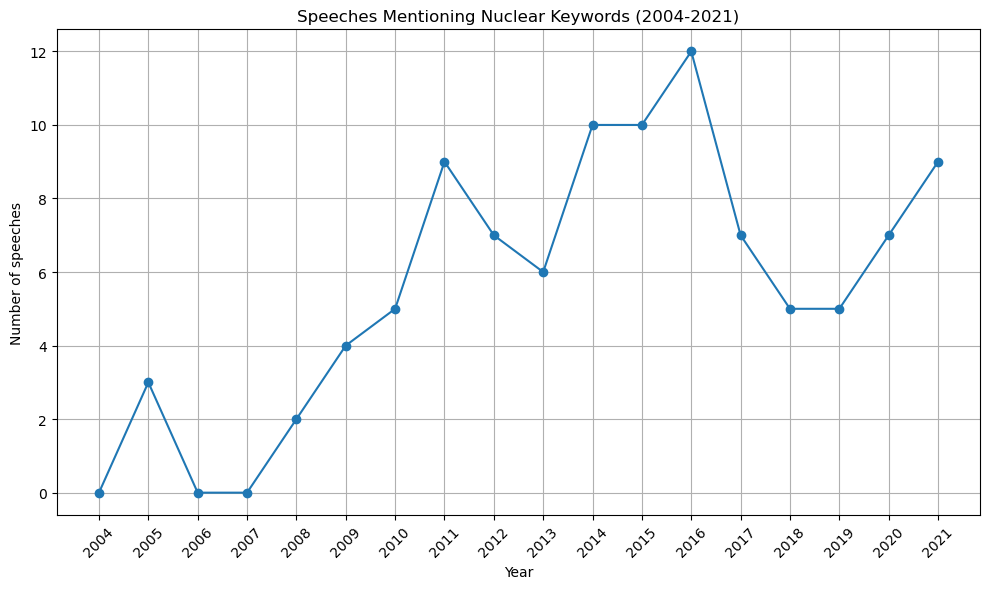

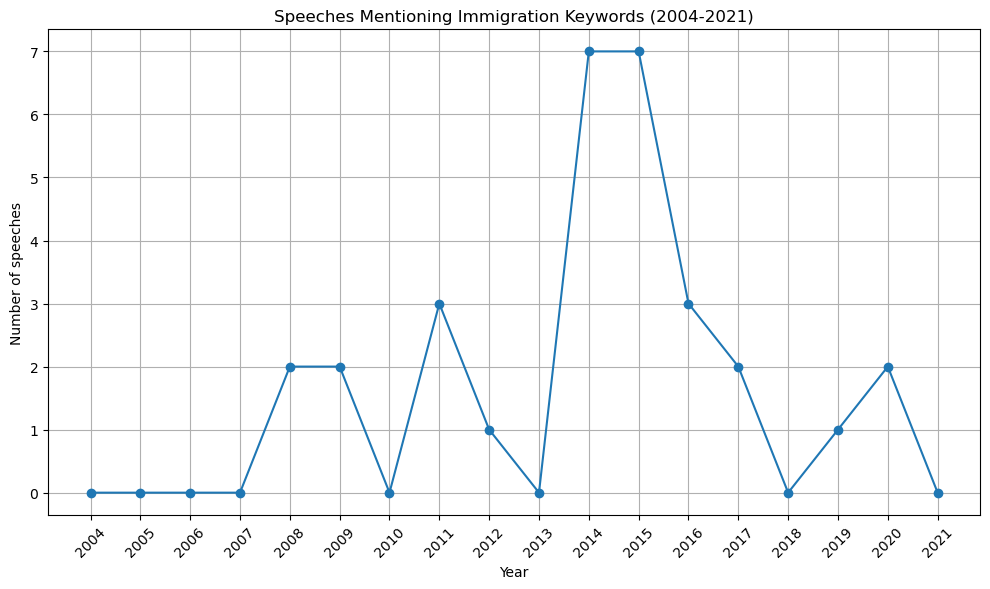

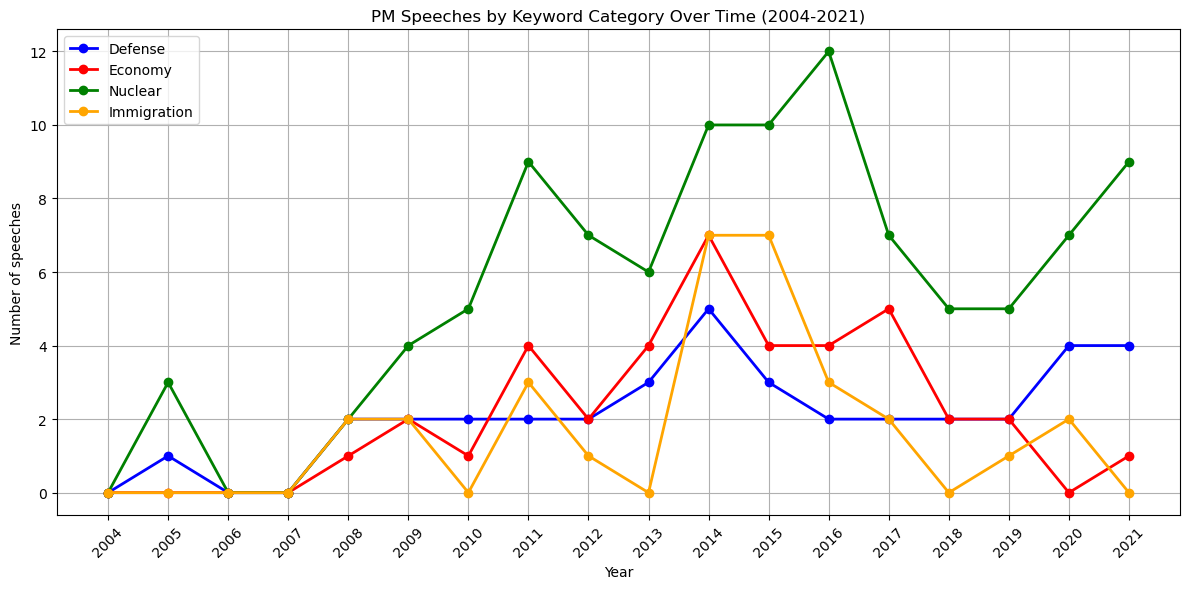

defense: 38 speeches mention this category's keywords
economy: 39 speeches mention this category's keywords
nuclear: 101 speeches mention this category's keywords
immigration: 31 speeches mention this category's keywords


In [4]:
#Speeches mentioning keywords in each category 
import pandas as pd
from src.speeches_keywords_ailie import (
    plot_category_trend_charts,
    plot_combined_category_trend_chart,
    count_category_matches, 
)

speeches_df = pd.read_csv("../data/clean/japan_speeches_cleaned.csv", index_col="date", parse_dates=True)

plot_category_trend_charts(speeches_df)
plot_combined_category_trend_chart(speeches_df)
category_matches = count_category_matches(speeches_df)


In [5]:
from src.speech_analysis_rework import build_top_political_phrases_df
top_political_phrases_df = build_top_political_phrases_df(speeches_df)
top_political_phrases_df

,phrase,categories,total_count,doc_freq
0,self defense forces,defense,14,8
1,japan u.s. alliance,nuclear,10,9
2,sustainable growth,economy,7,7
3,u.s.-japan alliance,nuclear,7,4
4,structural reforms,economy,6,4
5,japan us alliance,nuclear,5,5
6,chief of the japan self defense forces sdf,defense,5,5
7,self defence forces,defense,4,2
8,alliance of hope,nuclear,4,3
9,maritime self defense force,defense,3,3


## 5. Graph and Analyze
Graphs for comparative analysis

#### 5a. Cyrus's graphs - title and descriptions?

#### 5b. Graphs combaring frequency of keyword occurence between news and speeches over time (2001 - 2021)
The following is the function [graph_articles.py](../src/graph_articles.py) used to graph this information and how it was called using Japan's data as an example:

In [ ]:
# Imports
from src.graph_articles import keyword_yearly_counts, plot_category

In [ ]:
# Read cleaned CSV data for Japan's news and speeches into dataframes
JPspeeches_df = pd.read_csv('../data/clean/japan_speeches_cleaned.csv')
JPnews_df = pd.read_csv('../data/clean/japan_news_cleaned.csv')

news_results = keyword_yearly_counts(JPnews_df)
speech_results = keyword_yearly_counts(JPspeeches_df)

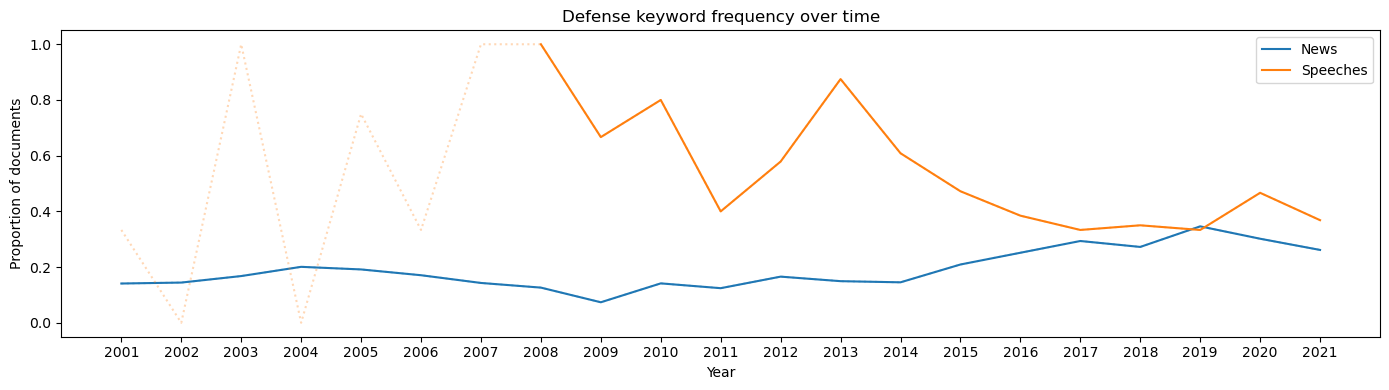

In [ ]:
# Output Graphs from graph_articles.py for 'defense' keyword group as an example

plot_category('defense', news_results, speech_results, labels=['News', 'Speeches'])

## 6. Results
What do the statistics and graphs say? What are the trends? this is where we would put all of the pngs just in markdown format for the graphs we decide to use in our final for japan, and the US and group 2 would discuss the results like trends in the graphs or significant points etc. and we can discuss how we interpret those trends in the conclusion

so i think if we are using the 4 comparative graphs from my .py for each country and the 2 that cyrus made that compare just within news and within speeches there should be 6 graphs per country, plus two word clouds for each(?) from ailie and cyrus' tokenization and whatever else Nina is making/has made with the ollama sentiment analysis like a table or something.

## 7. Conclusions
How do we interpret the results? What questions can we ask for the future/how can we improve??

mention how pdf manifestos didnt really work out, how we could make better comparisons, etc idk